# Análisis exploratorio del negocio

En este notebook analizo ventas, margen, inventario, sobrestock y oportunidades de mejora para el caso de consultoría de Cementos Andinos del Sur S.A.C.

El objetivo es convertir los datos operativos simulados en hallazgos de negocio que luego pueda presentar en el dashboard y en el informe ejecutivo.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"

In [2]:
ventas = pd.read_csv(DATA_DIR / "fact_ventas.csv", parse_dates=["fecha", "fecha_mes"])
inventario = pd.read_csv(DATA_DIR / "fact_inventario.csv", parse_dates=["fecha_corte", "fecha_mes"])
productos = pd.read_csv(DATA_DIR / "dim_producto.csv")
canales = pd.read_csv(DATA_DIR / "dim_canal.csv")
zonas = pd.read_csv(DATA_DIR / "dim_zona.csv")
metas = pd.read_csv(DATA_DIR / "fact_metas.csv", parse_dates=["fecha_mes"])

print("Ventas:", ventas.shape)
print("Inventario:", inventario.shape)
print("Productos:", productos.shape)
print("Metas:", metas.shape)

Ventas: (46870, 14)
Inventario: (5760, 11)
Productos: (32, 10)
Metas: (4608, 7)


In [3]:
ventas_netas = ventas["ingreso_neto"].sum()
margen_bruto = ventas["margen_bruto"].sum()
margen_pct = margen_bruto / ventas_netas
sobrestock_valorizado = inventario["sobrestock_valorizado"].sum()

resumen = pd.DataFrame({
    "KPI": [
        "Ventas netas",
        "Margen bruto",
        "Margen bruto %",
        "Sobrestock valorizado"
    ],
    "Valor": [
        ventas_netas,
        margen_bruto,
        margen_pct,
        sobrestock_valorizado
    ]
})

resumen

,KPI,Valor
0,Ventas netas,"925,593,305.92"
1,Margen bruto,"229,934,002.43"
2,Margen bruto %,0.25
3,Sobrestock valorizado,"34,381,294.62"


## Análisis de rentabilidad por producto

En esta sección analizo qué productos generan mayor venta, mayor margen y cuáles tienen baja rentabilidad relativa. Esto me ayuda a identificar oportunidades para optimizar el catálogo comercial.

In [4]:
ventas_prod = ventas.merge(
    productos[
        [
            "producto_id",
            "producto",
            "categoria",
            "subcategoria",
            "unidad_medida",
            "estado_catalogo",
            "precio_lista",
            "costo_estandar"
        ]
    ],
    on="producto_id",
    how="left"
)

ventas_prod.head()

,venta_id,fecha,fecha_mes,producto_id,cliente_id,canal_id,zona_id,cantidad,precio_unitario,ingreso_bruto,descuento,ingreso_neto,costo_total,margen_bruto,producto,categoria,subcategoria,unidad_medida,estado_catalogo,precio_lista,costo_estandar
0,V0000001,2023-01-01,2023-01-01,PROD014,CLI037,CAN02,ZON03,17.66,275.63,"4,867.63",218.50,"4,649.13","3,455.74","1,193.39",Concreto f'c 210 kg/cm2,Concreto premezclado,Estandar,m3,Activo,275.00,199.00
1,V0000002,2023-01-01,2023-01-01,PROD002,CLI058,CAN03,ZON07,103.18,30.59,"3,156.28",71.20,"3,085.08","2,215.68",869.40,Cemento Portland IP 42.5kg,Cemento embolsado,Puzolanico,bolsa_42_5kg,Activo,30.50,21.00
2,V0000003,2023-01-01,2023-01-01,PROD012,CLI078,CAN04,ZON01,90.12,418.69,"37,732.34","1,160.87","36,571.47","28,140.58","8,430.89",Cemento Tipo V Granel,Cemento granel,Especial,tonelada,Observar,418.00,304.00
3,V0000004,2023-01-01,2023-01-01,PROD020,CLI063,CAN03,ZON01,152.54,42.92,"6,547.02",100.44,"6,446.58","4,173.20","2,273.38",Arena fina zarandeada,Agregados,Arena,tonelada,Activo,43.00,28.00
4,V0000005,2023-01-01,2023-01-01,PROD001,CLI075,CAN04,ZON01,936.17,32.59,"30,509.78","1,105.13","29,404.65","20,471.47","8,933.18",Cemento Portland Tipo I 42.5kg,Cemento embolsado,Portland,bolsa_42_5kg,Activo,32.00,22.40


In [5]:
rentabilidad_producto = (
    ventas_prod
    .groupby(["producto_id", "producto", "categoria", "estado_catalogo"], as_index=False)
    .agg(
        ventas_netas=("ingreso_neto", "sum"),
        costo_total=("costo_total", "sum"),
        margen_bruto=("margen_bruto", "sum"),
        cantidad_vendida=("cantidad", "sum"),
        transacciones=("venta_id", "count")
    )
)

rentabilidad_producto["margen_pct"] = (
    rentabilidad_producto["margen_bruto"] / rentabilidad_producto["ventas_netas"]
)

rentabilidad_producto["participacion_ventas_pct"] = (
    rentabilidad_producto["ventas_netas"] / rentabilidad_producto["ventas_netas"].sum()
)

rentabilidad_producto = rentabilidad_producto.sort_values(
    "margen_bruto",
    ascending=False
)

rentabilidad_producto.head(10)

,producto_id,producto,categoria,estado_catalogo,ventas_netas,costo_total,margen_bruto,cantidad_vendida,transacciones,margen_pct,participacion_ventas_pct
9,PROD010,Cemento Portland IP Granel,Cemento granel,Activo,"124,507,893.19","92,208,655.81","32,299,237.38","384,394.67",2328,0.26,0.13
8,PROD009,Cemento Portland Tipo I Granel,Cemento granel,Activo,"116,311,908.85","86,194,726.88","30,117,181.97","342,177.52",2095,0.26,0.13
10,PROD011,Cemento Alta Resistencia Granel,Cemento granel,Activo,"76,293,382.62","57,252,083.21","19,041,299.41","196,774.87",1327,0.25,0.08
1,PROD002,Cemento Portland IP 42.5kg,Cemento embolsado,Activo,"66,135,589.51","48,292,906.94","17,842,682.57","2,255,368.71",3702,0.27,0.07
0,PROD001,Cemento Portland Tipo I 42.5kg,Cemento embolsado,Activo,"65,140,227.53","48,398,917.91","16,741,309.62","2,118,113.00",3484,0.26,0.07
2,PROD003,Cemento Alta Resistencia 42.5kg,Cemento embolsado,Activo,"55,841,693.40","41,188,345.09","14,653,348.31","1,569,158.72",2663,0.26,0.06
3,PROD004,Cemento Antisalitre 42.5kg,Cemento embolsado,Activo,"43,741,726.46","32,310,592.63","11,431,133.83","1,246,712.42",2247,0.26,0.05
11,PROD012,Cemento Tipo V Granel,Cemento granel,Observar,"43,753,520.23","33,884,616.15","9,868,904.08","109,345.45",798,0.23,0.05
14,PROD015,Concreto f'c 280 kg/cm2,Concreto premezclado,Activo,"37,550,542.13","28,679,750.45","8,870,791.68","123,318.93",1718,0.24,0.04
5,PROD006,Cemento Albanileria 42.5kg,Cemento embolsado,Activo,"33,471,364.95","24,719,942.60","8,751,422.35","1,243,845.72",2216,0.26,0.04


In [6]:
top_margen = rentabilidad_producto.head(10)[
    [
        "producto",
        "categoria",
        "ventas_netas",
        "margen_bruto",
        "margen_pct",
        "participacion_ventas_pct"
    ]
]

top_margen

,producto,categoria,ventas_netas,margen_bruto,margen_pct,participacion_ventas_pct
9,Cemento Portland IP Granel,Cemento granel,"124,507,893.19","32,299,237.38",0.26,0.13
8,Cemento Portland Tipo I Granel,Cemento granel,"116,311,908.85","30,117,181.97",0.26,0.13
10,Cemento Alta Resistencia Granel,Cemento granel,"76,293,382.62","19,041,299.41",0.25,0.08
1,Cemento Portland IP 42.5kg,Cemento embolsado,"66,135,589.51","17,842,682.57",0.27,0.07
0,Cemento Portland Tipo I 42.5kg,Cemento embolsado,"65,140,227.53","16,741,309.62",0.26,0.07
2,Cemento Alta Resistencia 42.5kg,Cemento embolsado,"55,841,693.40","14,653,348.31",0.26,0.06
3,Cemento Antisalitre 42.5kg,Cemento embolsado,"43,741,726.46","11,431,133.83",0.26,0.05
11,Cemento Tipo V Granel,Cemento granel,"43,753,520.23","9,868,904.08",0.23,0.05
14,Concreto f'c 280 kg/cm2,Concreto premezclado,"37,550,542.13","8,870,791.68",0.24,0.04
5,Cemento Albanileria 42.5kg,Cemento embolsado,"33,471,364.95","8,751,422.35",0.26,0.04


In [7]:
baja_rentabilidad = (
    rentabilidad_producto
    .sort_values("margen_pct", ascending=True)
    [
        [
            "producto",
            "categoria",
            "estado_catalogo",
            "ventas_netas",
            "margen_bruto",
            "margen_pct",
            "participacion_ventas_pct"
        ]
    ]
    .head(10)
)

baja_rentabilidad

,producto,categoria,estado_catalogo,ventas_netas,margen_bruto,margen_pct,participacion_ventas_pct
31,Cemento blanco decorativo,Cemento embolsado,Descontinuar,"3,920,752.57","512,814.06",0.13,0.00
30,Microsilice industrial,Complementarios,Observar,"736,862.69","106,091.78",0.14,0.00
7,Cemento Economico 42.5kg,Cemento embolsado,Observar,"24,146,136.24","3,635,869.22",0.15,0.03
17,Concreto autocompactante,Concreto premezclado,Observar,"12,934,334.13","2,206,498.88",0.17,0.01
28,Sellador para concreto,Complementarios,Descontinuar,"546,547.32","94,346.79",0.17,0.00
25,Mortero seco embolsado,Complementarios,Activo,"1,146,701.85","228,251.08",0.20,0.00
27,Aditivo impermeabilizante,Complementarios,Observar,"727,193.49","149,408.31",0.21,0.00
29,Curador quimico,Complementarios,Observar,"602,150.46","125,610.48",0.21,0.00
16,Concreto bombeable,Concreto premezclado,Activo,"23,759,806.35","5,208,382.62",0.22,0.03
15,Concreto f'c 350 kg/cm2,Concreto premezclado,Activo,"28,939,978.93","6,377,621.67",0.22,0.03


In [8]:
def clasificar_rentabilidad(margen_pct):
    if margen_pct >= 0.27:
        return "Alta rentabilidad"
    elif margen_pct >= 0.20:
        return "Rentabilidad media"
    else:
        return "Baja rentabilidad"

rentabilidad_producto["clasificacion_rentabilidad"] = rentabilidad_producto["margen_pct"].apply(
    clasificar_rentabilidad
)

resumen_clasificacion = (
    rentabilidad_producto
    .groupby("clasificacion_rentabilidad", as_index=False)
    .agg(
        productos=("producto_id", "count"),
        ventas_netas=("ventas_netas", "sum"),
        margen_bruto=("margen_bruto", "sum")
    )
)

resumen_clasificacion["margen_pct"] = (
    resumen_clasificacion["margen_bruto"] / resumen_clasificacion["ventas_netas"]
)

resumen_clasificacion

,clasificacion_rentabilidad,productos,ventas_netas,margen_bruto,margen_pct
0,Alta rentabilidad,5,"43,898,718.41","13,402,760.32",0.31
1,Baja rentabilidad,6,"43,431,334.80","6,783,871.81",0.16
2,Rentabilidad media,21,"838,263,252.71","209,747,370.30",0.25


### Hallazgo 1: concentración de rentabilidad en productos cementeros principales

Identifiqué que la mayor parte del margen bruto se concentra en productos cementeros de alta rotación, especialmente cemento granel y cemento embolsado. Los productos líderes por margen son Cemento Portland IP Granel, Cemento Portland Tipo I Granel y Cemento Alta Resistencia Granel.

Esto me indica que el negocio depende principalmente de su portafolio cementero tradicional, por lo que cualquier decisión de compras, producción o abastecimiento debe priorizar la disponibilidad de estos productos.

### Hallazgo 2: productos de baja rentabilidad que requieren revisión de catálogo

Detecté productos con baja rentabilidad relativa, como Cemento blanco decorativo, Microsílice industrial, Cemento Económico 42.5kg y Concreto autocompactante. Algunos de estos productos ya aparecen clasificados como "Observar" o "Descontinuar", lo cual refuerza la necesidad de revisar si conviene mantenerlos, ajustar precios, renegociar costos o reducir inventario asociado.

Este análisis no implica eliminar automáticamente esos productos, sino priorizarlos para una evaluación comercial y operativa.

## Análisis de inventario y sobrestock

En esta sección analizo el estado del inventario para identificar productos con exceso de stock, capital inmovilizado y posibles oportunidades de ahorro.

In [9]:
inventario_prod = inventario.merge(
    productos[
        [
            "producto_id",
            "producto",
            "categoria",
            "estado_catalogo",
            "costo_estandar"
        ]
    ],
    on="producto_id",
    how="left"
)

inventario_prod.head()

,fecha_corte,fecha_mes,producto_id,almacen_id,stock_unidades,stock_valorizado,stock_seguridad,stock_maximo,sobrestock_unidades,sobrestock_valorizado,estado_stock,producto,categoria,estado_catalogo,costo_estandar
0,2023-01-31,2023-01-01,PROD001,ALM01,"4,640.07","103,937.57","1,501.42","7,775.21",0.00,0.00,Normal,Cemento Portland Tipo I 42.5kg,Cemento embolsado,Activo,22.40
1,2023-01-31,2023-01-01,PROD001,ALM02,"7,731.86","173,193.66","2,501.85","12,956.02",0.00,0.00,Normal,Cemento Portland Tipo I 42.5kg,Cemento embolsado,Activo,22.40
2,2023-01-31,2023-01-01,PROD001,ALM03,"7,736.14","173,289.54","2,503.24","12,963.20",0.00,0.00,Normal,Cemento Portland Tipo I 42.5kg,Cemento embolsado,Activo,22.40
3,2023-01-31,2023-01-01,PROD001,ALM04,"7,590.41","170,025.18","2,456.08","12,719.01",0.00,0.00,Normal,Cemento Portland Tipo I 42.5kg,Cemento embolsado,Activo,22.40
4,2023-01-31,2023-01-01,PROD001,ALM05,"5,111.57","114,499.17","1,653.99","8,565.29",0.00,0.00,Normal,Cemento Portland Tipo I 42.5kg,Cemento embolsado,Activo,22.40


In [10]:
estado_inventario = (
    inventario_prod
    .groupby("estado_stock", as_index=False)
    .agg(
        registros=("producto_id", "count"),
        stock_valorizado=("stock_valorizado", "sum"),
        sobrestock_valorizado=("sobrestock_valorizado", "sum")
    )
)

estado_inventario["participacion_stock_pct"] = (
    estado_inventario["stock_valorizado"] / estado_inventario["stock_valorizado"].sum()
)

estado_inventario

,estado_stock,registros,stock_valorizado,sobrestock_valorizado,participacion_stock_pct
0,Critico,108,"3,335,515.85",0.00,0.00
1,Normal,4355,"502,390,327.05",0.00,0.74
2,Sobrestock,1297,"173,034,274.44","34,381,294.62",0.25


In [11]:
sobrestock_producto = (
    inventario_prod
    .groupby(["producto_id", "producto", "categoria", "estado_catalogo"], as_index=False)
    .agg(
        stock_valorizado=("stock_valorizado", "sum"),
        sobrestock_valorizado=("sobrestock_valorizado", "sum"),
        sobrestock_unidades=("sobrestock_unidades", "sum")
    )
)

sobrestock_producto["sobrestock_pct"] = (
    sobrestock_producto["sobrestock_valorizado"] / sobrestock_producto["stock_valorizado"]
)

top_sobrestock = (
    sobrestock_producto
    .sort_values("sobrestock_valorizado", ascending=False)
    .head(10)
)

top_sobrestock

,producto_id,producto,categoria,estado_catalogo,stock_valorizado,sobrestock_valorizado,sobrestock_unidades,sobrestock_pct
8,PROD009,Cemento Portland Tipo I Granel,Cemento granel,Activo,"87,544,289.04","6,340,462.83","25,669.89",0.07
11,PROD012,Cemento Tipo V Granel,Cemento granel,Observar,"48,102,819.84","5,712,831.84","18,792.21",0.12
10,PROD011,Cemento Alta Resistencia Granel,Cemento granel,Activo,"49,921,665.90","2,658,787.80","9,329.08",0.05
6,PROD007,Cemento Premium Acabados 42.5kg,Cemento embolsado,Observar,"21,063,647.38","2,123,327.38","85,618.04",0.10
17,PROD018,Concreto autocompactante,Concreto premezclado,Observar,"15,493,165.60","2,118,622.25","5,967.95",0.14
31,PROD032,Cemento blanco decorativo,Cemento embolsado,Descontinuar,"6,541,918.20","2,100,882.96","58,357.86",0.32
9,PROD010,Cemento Portland IP Granel,Cemento granel,Activo,"79,996,006.90","2,029,643.30","8,636.78",0.03
7,PROD008,Cemento Economico 42.5kg,Cemento embolsado,Observar,"25,595,561.72","1,959,803.47","92,443.56",0.08
3,PROD004,Cemento Antisalitre 42.5kg,Cemento embolsado,Activo,"31,974,208.39","1,924,704.30","75,775.76",0.06
2,PROD003,Cemento Alta Resistencia 42.5kg,Cemento embolsado,Activo,"38,097,225.06","1,228,220.99","47,790.70",0.03


In [12]:
sobrestock_categoria = (
    inventario_prod
    .groupby("categoria", as_index=False)
    .agg(
        stock_valorizado=("stock_valorizado", "sum"),
        sobrestock_valorizado=("sobrestock_valorizado", "sum"),
        sobrestock_unidades=("sobrestock_unidades", "sum")
    )
)

sobrestock_categoria["sobrestock_pct"] = (
    sobrestock_categoria["sobrestock_valorizado"] / sobrestock_categoria["stock_valorizado"]
)

sobrestock_categoria.sort_values("sobrestock_valorizado", ascending=False)

,categoria,stock_valorizado,sobrestock_valorizado,sobrestock_unidades,sobrestock_pct
2,Cemento granel,"265,564,781.68","16,741,725.77","62,427.96",0.06
1,Cemento embolsado,"253,940,960.62","10,590,051.95","418,121.29",0.04
4,Concreto premezclado,"120,831,665.27","4,825,661.07","18,366.85",0.04
0,Agregados,"33,236,380.84","1,640,483.23","48,421.21",0.05
3,Complementarios,"5,186,328.93","583,372.60","13,860.98",0.11


### Hallazgo 3: capital inmovilizado por sobrestock

Identifiqué que el inventario con estado de sobrestock representa una oportunidad importante de optimización. Aunque no todo el stock en sobrestock debe eliminarse, el exceso valorizado asciende a S/ 34.38M, lo que representa capital inmovilizado que podría liberarse mediante mejores políticas de reposición, compras y planificación de demanda.

La categoría con mayor sobrestock valorizado es Cemento granel, seguida por Cemento embolsado y Concreto premezclado. Esto indica que la oportunidad no está solo en productos menores, sino también en categorías centrales del negocio.

### Hallazgo 4: productos en observación o descontinuación mantienen inventario relevante

Detecté productos como Cemento Tipo V Granel, Cemento Premium Acabados, Concreto autocompactante y Cemento blanco decorativo dentro del ranking de mayor sobrestock. Esto es relevante porque varios de ellos ya están clasificados como "Observar" o "Descontinuar".

Esto me indica que existe una oportunidad de alinear mejor el catálogo comercial con las decisiones de inventario, evitando mantener capital inmovilizado en productos de baja prioridad estratégica.

## Priorización de oportunidades

En esta sección cruzo rentabilidad y sobrestock para identificar productos que deberían priorizarse en una propuesta de optimización. El objetivo no es solo mirar qué producto vende más, sino detectar dónde hay baja rentabilidad, exceso de inventario o riesgo de capital inmovilizado.

In [13]:
oportunidades = sobrestock_producto.merge(
    rentabilidad_producto[
        [
            "producto_id",
            "ventas_netas",
            "margen_bruto",
            "margen_pct",
            "participacion_ventas_pct",
            "clasificacion_rentabilidad"
        ]
    ],
    on="producto_id",
    how="left"
)

oportunidades["peso_sobrestock_pct"] = (
    oportunidades["sobrestock_valorizado"] / oportunidades["sobrestock_valorizado"].sum()
)

oportunidades.head()

,producto_id,producto,categoria,estado_catalogo,stock_valorizado,sobrestock_valorizado,sobrestock_unidades,sobrestock_pct,ventas_netas,margen_bruto,margen_pct,participacion_ventas_pct,clasificacion_rentabilidad,peso_sobrestock_pct
0,PROD001,Cemento Portland Tipo I 42.5kg,Cemento embolsado,Activo,"40,288,224.74","130,611.49","5,830.87",0.00,"65,140,227.53","16,741,309.62",0.26,0.07,Rentabilidad media,0.00
1,PROD002,Cemento Portland IP 42.5kg,Cemento embolsado,Activo,"42,985,692.12","447,769.56","21,322.36",0.01,"66,135,589.51","17,842,682.57",0.27,0.07,Rentabilidad media,0.01
2,PROD003,Cemento Alta Resistencia 42.5kg,Cemento embolsado,Activo,"38,097,225.06","1,228,220.99","47,790.70",0.03,"55,841,693.40","14,653,348.31",0.26,0.06,Rentabilidad media,0.04
3,PROD004,Cemento Antisalitre 42.5kg,Cemento embolsado,Activo,"31,974,208.39","1,924,704.30","75,775.76",0.06,"43,741,726.46","11,431,133.83",0.26,0.05,Rentabilidad media,0.06
4,PROD005,Cemento Tipo V 42.5kg,Cemento embolsado,Activo,"24,253,622.57","251,673.64","9,286.85",0.01,"35,469,760.15","8,623,640.46",0.24,0.04,Rentabilidad media,0.01


In [14]:
def recomendar_accion(row):
    if row["estado_catalogo"] == "Descontinuar" and row["sobrestock_valorizado"] > 0:
        return "Liquidar inventario y retirar del catálogo"
    elif row["clasificacion_rentabilidad"] == "Baja rentabilidad" and row["sobrestock_valorizado"] > 0:
        return "Revisar precio, costo y política de reposición"
    elif row["estado_catalogo"] == "Observar" and row["sobrestock_valorizado"] > 0:
        return "Reducir compras y monitorear demanda"
    elif row["sobrestock_valorizado"] > 0 and row["margen_pct"] >= 0.25:
        return "Ajustar planificación sin afectar disponibilidad"
    else:
        return "Mantener seguimiento"

oportunidades["accion_sugerida"] = oportunidades.apply(recomendar_accion, axis=1)

oportunidades_priorizadas = (
    oportunidades
    .sort_values("sobrestock_valorizado", ascending=False)
    [
        [
            "producto",
            "categoria",
            "estado_catalogo",
            "ventas_netas",
            "margen_pct",
            "clasificacion_rentabilidad",
            "stock_valorizado",
            "sobrestock_valorizado",
            "sobrestock_pct",
            "accion_sugerida"
        ]
    ]
    .head(15)
)

oportunidades_priorizadas

,producto,categoria,estado_catalogo,ventas_netas,margen_pct,clasificacion_rentabilidad,stock_valorizado,sobrestock_valorizado,sobrestock_pct,accion_sugerida
8,Cemento Portland Tipo I Granel,Cemento granel,Activo,"116,311,908.85",0.26,Rentabilidad media,"87,544,289.04","6,340,462.83",0.07,Ajustar planificación sin afectar disponibilidad
11,Cemento Tipo V Granel,Cemento granel,Observar,"43,753,520.23",0.23,Rentabilidad media,"48,102,819.84","5,712,831.84",0.12,Reducir compras y monitorear demanda
10,Cemento Alta Resistencia Granel,Cemento granel,Activo,"76,293,382.62",0.25,Rentabilidad media,"49,921,665.90","2,658,787.80",0.05,Mantener seguimiento
6,Cemento Premium Acabados 42.5kg,Cemento embolsado,Observar,"21,641,587.74",0.23,Rentabilidad media,"21,063,647.38","2,123,327.38",0.10,Reducir compras y monitorear demanda
17,Concreto autocompactante,Concreto premezclado,Observar,"12,934,334.13",0.17,Baja rentabilidad,"15,493,165.60","2,118,622.25",0.14,"Revisar precio, costo y política de reposición"
31,Cemento blanco decorativo,Cemento embolsado,Descontinuar,"3,920,752.57",0.13,Baja rentabilidad,"6,541,918.20","2,100,882.96",0.32,Liquidar inventario y retirar del catálogo
9,Cemento Portland IP Granel,Cemento granel,Activo,"124,507,893.19",0.26,Rentabilidad media,"79,996,006.90","2,029,643.30",0.03,Ajustar planificación sin afectar disponibilidad
7,Cemento Economico 42.5kg,Cemento embolsado,Observar,"24,146,136.24",0.15,Baja rentabilidad,"25,595,561.72","1,959,803.47",0.08,"Revisar precio, costo y política de reposición"
3,Cemento Antisalitre 42.5kg,Cemento embolsado,Activo,"43,741,726.46",0.26,Rentabilidad media,"31,974,208.39","1,924,704.30",0.06,Ajustar planificación sin afectar disponibilidad
2,Cemento Alta Resistencia 42.5kg,Cemento embolsado,Activo,"55,841,693.40",0.26,Rentabilidad media,"38,097,225.06","1,228,220.99",0.03,Ajustar planificación sin afectar disponibilidad


In [15]:
sobrestock_total = oportunidades["sobrestock_valorizado"].sum()

escenarios_ahorro = pd.DataFrame({
    "escenario": [
        "Conservador",
        "Moderado",
        "Agresivo"
    ],
    "reduccion_sobrestock_pct": [
        0.25,
        0.40,
        0.60
    ]
})

escenarios_ahorro["ahorro_potencial"] = (
    sobrestock_total * escenarios_ahorro["reduccion_sobrestock_pct"]
)

escenarios_ahorro

,escenario,reduccion_sobrestock_pct,ahorro_potencial
0,Conservador,0.25,"8,595,323.65"
1,Moderado,0.40,"13,752,517.85"
2,Agresivo,0.60,"20,628,776.77"


In [16]:
ventas_netas_total = ventas["ingreso_neto"].sum()

escenarios_ahorro["ahorro_sobre_ventas_pct"] = (
    escenarios_ahorro["ahorro_potencial"] / ventas_netas_total
)

escenarios_ahorro

,escenario,reduccion_sobrestock_pct,ahorro_potencial,ahorro_sobre_ventas_pct
0,Conservador,0.25,"8,595,323.65",0.01
1,Moderado,0.40,"13,752,517.85",0.01
2,Agresivo,0.60,"20,628,776.77",0.02


In [17]:
escenarios_ahorro_formateado = escenarios_ahorro.copy()

escenarios_ahorro_formateado["reduccion_sobrestock_pct"] = (
    escenarios_ahorro_formateado["reduccion_sobrestock_pct"] * 100
)

escenarios_ahorro_formateado["ahorro_sobre_ventas_pct"] = (
    escenarios_ahorro_formateado["ahorro_sobre_ventas_pct"] * 100
)

escenarios_ahorro_formateado

,escenario,reduccion_sobrestock_pct,ahorro_potencial,ahorro_sobre_ventas_pct
0,Conservador,25.00,"8,595,323.65",0.93
1,Moderado,40.00,"13,752,517.85",1.49
2,Agresivo,60.00,"20,628,776.77",2.23


### Hallazgo 5: impacto económico estimado por reducción de sobrestock

Simulé tres escenarios de reducción de sobrestock. En un escenario conservador, reduciendo 25% del sobrestock valorizado, podría liberar aproximadamente S/ 8.60M. En un escenario moderado, el impacto subiría a S/ 13.75M, y en un escenario agresivo llegaría a S/ 20.63M.

Este resultado me permite conectar el análisis de inventario con impacto económico concreto, mostrando que una mejor planificación de compras, reposición y catálogo puede liberar capital inmovilizado.

### Hallazgo 6: no todo el sobrestock debe tratarse igual

Identifiqué que el sobrestock no debe gestionarse con una sola regla. En productos core como Cemento Portland Tipo I Granel o Cemento Portland IP Granel, la acción debe ser ajustar la planificación sin comprometer disponibilidad, porque son productos relevantes para ventas y margen.

En cambio, productos como Cemento blanco decorativo, Concreto autocompactante y Cemento Económico 42.5kg requieren una revisión más profunda porque combinan baja rentabilidad, estado de catálogo en observación o descontinuación, y exceso de inventario.

## Tendencias de ventas

En esta sección analizo la evolución mensual de ventas y margen para identificar patrones de crecimiento, estacionalidad o caídas relevantes.

In [18]:
ventas_mensuales = (
    ventas
    .groupby("fecha_mes", as_index=False)
    .agg(
        ventas_netas=("ingreso_neto", "sum"),
        margen_bruto=("margen_bruto", "sum"),
        transacciones=("venta_id", "count")
    )
)

ventas_mensuales["margen_pct"] = (
    ventas_mensuales["margen_bruto"] / ventas_mensuales["ventas_netas"]
)

ventas_mensuales.head()

,fecha_mes,ventas_netas,margen_bruto,transacciones,margen_pct
0,2023-01-01,"12,897,945.78","3,212,303.84",915,0.25
1,2023-02-01,"14,385,709.54","3,598,838.40",965,0.25
2,2023-03-01,"25,627,365.78","6,356,770.12",1333,0.25
3,2023-04-01,"25,960,347.11","6,400,023.18",1317,0.25
4,2023-05-01,"28,557,930.04","7,111,283.31",1362,0.25


In [19]:
ventas_mensuales["anio"] = ventas_mensuales["fecha_mes"].dt.year
ventas_mensuales["mes"] = ventas_mensuales["fecha_mes"].dt.month

ventas_anuales = (
    ventas_mensuales
    .groupby("anio", as_index=False)
    .agg(
        ventas_netas=("ventas_netas", "sum"),
        margen_bruto=("margen_bruto", "sum"),
        transacciones=("transacciones", "sum")
    )
)

ventas_anuales["margen_pct"] = (
    ventas_anuales["margen_bruto"] / ventas_anuales["ventas_netas"]
)

ventas_anuales

,anio,ventas_netas,margen_bruto,transacciones,margen_pct
0,2023,"273,813,466.00","68,055,633.78",14630,0.25
1,2024,"311,954,611.87","77,484,265.69",15767,0.25
2,2025,"339,825,228.05","84,394,102.96",16473,0.25


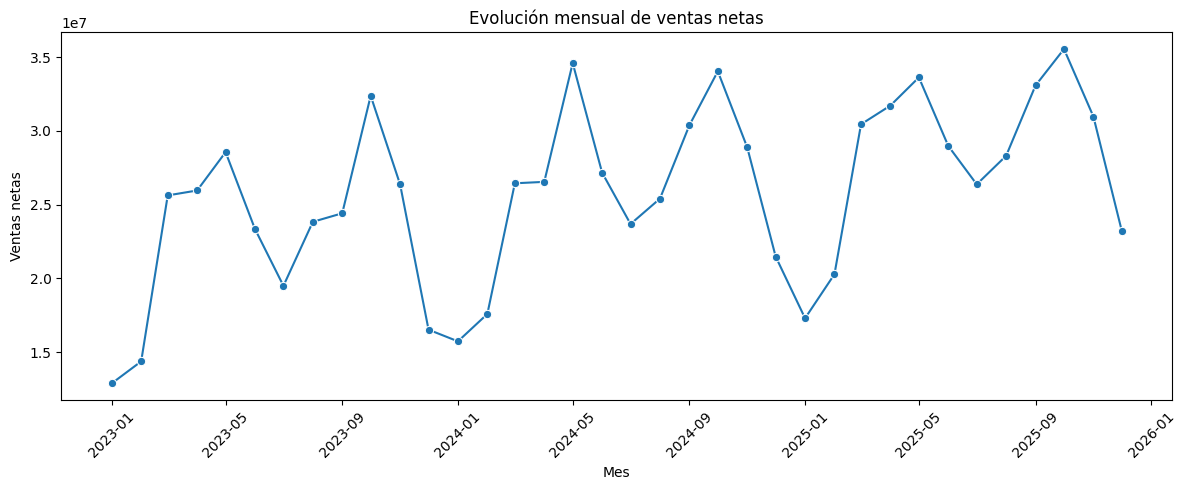

In [20]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=ventas_mensuales,
    x="fecha_mes",
    y="ventas_netas",
    marker="o"
)

plt.title("Evolución mensual de ventas netas")
plt.xlabel("Mes")
plt.ylabel("Ventas netas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
ventas_anuales["crecimiento_ventas_pct"] = (
    ventas_anuales["ventas_netas"].pct_change()
)

ventas_anuales

,anio,ventas_netas,margen_bruto,transacciones,margen_pct,crecimiento_ventas_pct
0,2023,"273,813,466.00","68,055,633.78",14630,0.25,NaN
1,2024,"311,954,611.87","77,484,265.69",15767,0.25,0.14
2,2025,"339,825,228.05","84,394,102.96",16473,0.25,0.09


### Hallazgo 7: crecimiento sostenido con margen estable

Identifiqué un crecimiento sostenido de ventas durante el periodo 2023-2025. Las ventas netas pasaron de S/ 273.81M en 2023 a S/ 311.95M en 2024 y S/ 339.83M en 2025.

Además, el margen bruto se mantuvo alrededor del 25%, lo que indica que el crecimiento no se logró sacrificando de forma significativa la rentabilidad bruta. Esto fortalece la posición del negocio, pero también exige una mejor planificación de inventario para evitar que el crecimiento comercial genere capital inmovilizado.

## Cumplimiento de metas comerciales

En esta sección comparo las ventas reales contra las metas definidas para evaluar el nivel de cumplimiento comercial por periodo.

In [22]:
ventas_mes_producto = (
    ventas
    .groupby(["fecha_mes", "producto_id"], as_index=False)
    .agg(
        ventas_reales=("ingreso_neto", "sum"),
        cantidad_real=("cantidad", "sum")
    )
)

metas_mes_producto = (
    metas
    .groupby(["fecha_mes", "producto_id"], as_index=False)
    .agg(
        meta_ventas=("meta_ventas", "sum"),
        meta_cantidad=("meta_cantidad", "sum"),
        meta_margen=("meta_margen", "sum")
    )
)

cumplimiento = ventas_mes_producto.merge(
    metas_mes_producto,
    on=["fecha_mes", "producto_id"],
    how="left"
)

cumplimiento["cumplimiento_ventas_pct"] = (
    cumplimiento["ventas_reales"] / cumplimiento["meta_ventas"]
)

cumplimiento.head()

,fecha_mes,producto_id,ventas_reales,cantidad_real,meta_ventas,meta_cantidad,meta_margen,cumplimiento_ventas_pct
0,2023-01-01,PROD001,"1,045,659.84","33,942.47","1,071,745.35","34,986.39","321,523.62",0.98
1,2023-01-01,PROD002,"1,192,780.02","40,612.28","1,191,492.84","40,779.07","371,150.01",1.00
2,2023-01-01,PROD003,"720,041.59","20,193.13","727,062.94","20,508.16","222,045.02",0.99
3,2023-01-01,PROD004,"497,996.33","14,248.57","458,284.75","13,106.97","139,364.40",1.09
4,2023-01-01,PROD005,"563,745.30","15,413.76","529,331.53","14,541.84","151,812.28",1.07


In [23]:
cumplimiento["anio"] = cumplimiento["fecha_mes"].dt.year

cumplimiento_anual = (
    cumplimiento
    .groupby("anio", as_index=False)
    .agg(
        ventas_reales=("ventas_reales", "sum"),
        meta_ventas=("meta_ventas", "sum"),
        cantidad_real=("cantidad_real", "sum"),
        meta_cantidad=("meta_cantidad", "sum")
    )
)

cumplimiento_anual["cumplimiento_ventas_pct"] = (
    cumplimiento_anual["ventas_reales"] / cumplimiento_anual["meta_ventas"]
)

cumplimiento_anual["cumplimiento_cantidad_pct"] = (
    cumplimiento_anual["cantidad_real"] / cumplimiento_anual["meta_cantidad"]
)

cumplimiento_anual

,anio,ventas_reales,meta_ventas,cantidad_real,meta_cantidad,cumplimiento_ventas_pct,cumplimiento_cantidad_pct
0,2023,"273,813,466.00","277,454,567.56","4,071,132.21","4,108,985.62",0.99,0.99
1,2024,"311,954,611.87","314,441,303.84","4,669,581.00","4,696,800.74",0.99,0.99
2,2025,"339,825,228.05","340,244,245.69","5,016,322.27","5,031,327.06",1.00,1.00


In [24]:
cumplimiento_producto = (
    cumplimiento
    .groupby("producto_id", as_index=False)
    .agg(
        ventas_reales=("ventas_reales", "sum"),
        meta_ventas=("meta_ventas", "sum")
    )
)

cumplimiento_producto["cumplimiento_ventas_pct"] = (
    cumplimiento_producto["ventas_reales"] / cumplimiento_producto["meta_ventas"]
)

cumplimiento_producto = cumplimiento_producto.merge(
    productos[["producto_id", "producto", "categoria", "estado_catalogo"]],
    on="producto_id",
    how="left"
)

menor_cumplimiento = (
    cumplimiento_producto
    .sort_values("cumplimiento_ventas_pct")
    .head(10)
)

menor_cumplimiento

,producto_id,ventas_reales,meta_ventas,cumplimiento_ventas_pct,producto,categoria,estado_catalogo
16,PROD017,"23,759,806.35","24,495,044.47",0.97,Concreto bombeable,Concreto premezclado,Activo
10,PROD011,"76,293,382.62","78,421,665.52",0.97,Cemento Alta Resistencia Granel,Cemento granel,Activo
29,PROD030,"602,150.46","618,697.79",0.97,Curador quimico,Complementarios,Observar
7,PROD008,"24,146,136.24","24,639,069.74",0.98,Cemento Economico 42.5kg,Cemento embolsado,Observar
13,PROD014,"36,493,052.33","37,172,627.12",0.98,Concreto f'c 210 kg/cm2,Concreto premezclado,Activo
30,PROD031,"736,862.69","750,426.25",0.98,Microsilice industrial,Complementarios,Observar
31,PROD032,"3,920,752.57","3,973,986.88",0.99,Cemento blanco decorativo,Cemento embolsado,Descontinuar
12,PROD013,"22,423,425.83","22,697,761.65",0.99,Concreto f'c 175 kg/cm2,Concreto premezclado,Activo
11,PROD012,"43,753,520.23","44,255,163.03",0.99,Cemento Tipo V Granel,Cemento granel,Observar
25,PROD026,"1,146,701.85","1,159,408.63",0.99,Mortero seco embolsado,Complementarios,Activo


### Hallazgo 8: cumplimiento comercial estable, pero con oportunidades operativas

Identifiqué que el cumplimiento comercial anual se mantiene cerca del 99% y llega prácticamente al 100% en 2025. Esto indica que el negocio tiene una ejecución comercial estable y que la demanda proyectada está relativamente alineada con las ventas reales.

Sin embargo, al cruzar este resultado con el análisis de inventario, observé que cumplir metas no necesariamente implica eficiencia operativa. A pesar del buen desempeño comercial, existen productos con sobrestock, baja rentabilidad o estado de catálogo en observación, lo que evidencia oportunidades para mejorar compras, reposición y planificación.

## Hallazgos ejecutivos

En esta sección sintetizo los principales hallazgos del análisis exploratorio para usarlos como base del informe ejecutivo y del dashboard.

In [25]:
hallazgos = pd.DataFrame({
    "hallazgo": [
        "Crecimiento sostenido de ventas",
        "Margen bruto estable",
        "Rentabilidad concentrada en productos cementeros principales",
        "Productos de baja rentabilidad requieren revisión",
        "Sobrestock valorizado relevante",
        "No todo el sobrestock debe tratarse igual",
        "Impacto económico potencial por reducción de sobrestock",
        "Cumplimiento comercial estable"
    ],
    "evidencia": [
        "Las ventas netas crecieron de S/ 273.81M en 2023 a S/ 339.83M en 2025.",
        "El margen bruto se mantuvo alrededor del 25% durante el periodo analizado.",
        "Los principales productos por margen pertenecen a cemento granel y cemento embolsado.",
        "Productos como Cemento blanco decorativo, Cemento Económico 42.5kg y Concreto autocompactante muestran baja rentabilidad relativa.",
        "El sobrestock valorizado total asciende a aproximadamente S/ 34.38M.",
        "Productos core requieren ajuste de planificación, mientras que productos en observación o descontinuación requieren acciones de catálogo.",
        "La reducción de 40% del sobrestock podría liberar aproximadamente S/ 13.75M.",
        "El cumplimiento anual de ventas se mantiene entre 99% y 100%."
    ],
    "implicancia_negocio": [
        "El negocio muestra tracción comercial y oportunidad de escalar con mejor control operativo.",
        "La empresa crece sin deteriorar significativamente la rentabilidad bruta.",
        "Las decisiones de producción, abastecimiento y disponibilidad deben priorizar el portafolio core.",
        "Se debe revisar precio, costo, demanda y permanencia en catálogo.",
        "Existe capital inmovilizado que puede gestionarse mediante mejores políticas de inventario.",
        "La estrategia debe diferenciar entre productos core y productos de baja prioridad.",
        "La optimización de inventario puede generar impacto financiero medible.",
        "El foco de mejora está menos en vender más y más en operar con mayor eficiencia."
    ],
    "accion_recomendada": [
        "Mantener seguimiento de crecimiento mensual y estacionalidad.",
        "Monitorear costos para sostener margen.",
        "Asegurar disponibilidad de productos core.",
        "Revisar política comercial y de catálogo.",
        "Reducir compras o redistribuir inventario excedente.",
        "Diseñar reglas diferenciadas de reposición.",
        "Implementar escenario moderado como meta inicial.",
        "Complementar metas comerciales con KPIs operativos."
    ]
})

hallazgos

,hallazgo,evidencia,implicancia_negocio,accion_recomendada
0,Crecimiento sostenido de ventas,Las ventas netas crecieron de S/ 273.81M en 20...,El negocio muestra tracción comercial y oportu...,Mantener seguimiento de crecimiento mensual y ...
1,Margen bruto estable,El margen bruto se mantuvo alrededor del 25% d...,La empresa crece sin deteriorar significativam...,Monitorear costos para sostener margen.
2,Rentabilidad concentrada en productos cementer...,Los principales productos por margen pertenece...,"Las decisiones de producción, abastecimiento y...",Asegurar disponibilidad de productos core.
3,Productos de baja rentabilidad requieren revisión,"Productos como Cemento blanco decorativo, Ceme...","Se debe revisar precio, costo, demanda y perma...",Revisar política comercial y de catálogo.
4,Sobrestock valorizado relevante,El sobrestock valorizado total asciende a apro...,Existe capital inmovilizado que puede gestiona...,Reducir compras o redistribuir inventario exce...
5,No todo el sobrestock debe tratarse igual,Productos core requieren ajuste de planificaci...,La estrategia debe diferenciar entre productos...,Diseñar reglas diferenciadas de reposición.
6,Impacto económico potencial por reducción de s...,La reducción de 40% del sobrestock podría libe...,La optimización de inventario puede generar im...,Implementar escenario moderado como meta inicial.
7,Cumplimiento comercial estable,El cumplimiento anual de ventas se mantiene en...,El foco de mejora está menos en vender más y m...,Complementar metas comerciales con KPIs operat...


In [26]:
OUTPUT_DIR = BASE_DIR / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)

hallazgos.to_csv(
    OUTPUT_DIR / "hallazgos_exploratorios.csv",
    index=False,
    encoding="utf-8-sig"
)

escenarios_ahorro.to_csv(
    OUTPUT_DIR / "escenarios_ahorro.csv",
    index=False,
    encoding="utf-8-sig"
)

oportunidades_priorizadas.to_csv(
    OUTPUT_DIR / "oportunidades_priorizadas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivos exportados correctamente.")

Archivos exportados correctamente.
